# Notebook 02: Análisis exploratorio de robos y hurtos en CABA

**Proyecto:** Análisis y estimación del riesgo de robos y hurtos en CABA  
**Fuente:** Dataset de delitos de 2023 procesado en el Notebook 01  
**Objetivo:** Describir la distribución temporal y espacial de los hechos contra la propiedad, detectar concentraciones y generar variables e hipótesis útiles para las etapas posteriores del trabajo.

## Decisión metodológica sobre Robo y Hurto

El dataset conserva la clasificación jurídica original, pero en este notebook **Robo y Hurto se analizan conjuntamente** bajo la categoría analítica `ROBO O HURTO`.

La distinción jurídica depende, en términos generales, de la existencia de fuerza en las cosas o violencia en las personas. Esa diferencia puede explicar por sí misma parte de las variaciones observadas entre horarios y modalidades, pero **no constituye una pregunta relevante para este trabajo práctico**. Por ese motivo:

- se filtran ambos tipos de delito;
- se conserva la columna `tipo` únicamente para trazabilidad;
- no se presentan gráficos ni conclusiones comparando Robo contra Hurto;
- el análisis se concentra en **cuándo y dónde se registran los hechos**, además del uso informado de armas o motos.

## Punto de partida

El Notebook 01 aplicó una limpieza conservadora y auditable:

- 348 registros descartados por coordenadas vacías o no numéricas;
- 2.779 registros descartados por coordenadas `0,0`;
- 31 registros descartados por estar geolocalizados fuera de CABA y no tener barrio/comuna;
- 3.158 descartes en total;
- 152.739 registros válidos dentro de CABA.

Las cantidades se verifican nuevamente al cargar el archivo limpio.

## 1. Configuración del entorno

El código detecta automáticamente si el notebook se ejecuta desde la carpeta `notebooks` o desde la raíz del proyecto.

Estructura esperada:

```text
CienciaDatosDelitosTPO/
├── datasets/
│   ├── raw/
│   └── processed/
│       └── delitos_2023_caba_limpio.csv
├── notebooks/
│   ├── 01_data_cleaning_caba.ipynb
│   └── 02_exploratory_analysis_caba.ipynb
└── reports/
    ├── figures/
    └── tables/
```

Las carpetas de resultados se crean automáticamente.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ------------------------------------------------------------
# Detección de la raíz del proyecto
# ------------------------------------------------------------
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name.lower() in {"notebook", "notebooks"}:
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

PROCESSED_DATA_DIR = PROJECT_ROOT / "datasets" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Localización del dataset limpio
# ------------------------------------------------------------
clean_file_candidates = [
    PROCESSED_DATA_DIR / "delitos_2023_caba_limpio.csv",
    PROJECT_ROOT / "data" / "processed" / "delitos_2023_caba_limpio.csv",
    PROJECT_ROOT / "data" / "processed" / "cleaned_crime_data.csv",
    Path("/mnt/data/datasets/processed/delitos_2023_caba_limpio.csv"),
]

CLEAN_FILE = next(
    (path for path in clean_file_candidates if path.exists()),
    None
)

if CLEAN_FILE is None:
    expected_paths = "\n".join(f" - {path}" for path in clean_file_candidates)
    raise FileNotFoundError(
        "No se encontró el dataset limpio generado por el Notebook 01. "
        "Ejecutá primero ese notebook o ubicá el archivo en alguna de estas rutas:\n"
        f"{expected_paths}"
    )

# Configuración de visualización de tablas.
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

def finish_plot(filename):
    """Ajusta, guarda y muestra cada gráfico."""
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Dataset limpio: {CLEAN_FILE}")
print(f"Figuras: {FIGURES_DIR}")
print(f"Tablas: {TABLES_DIR}")

Raíz del proyecto: C:\Users\nikko\CienciaDatosDelitosTPO
Dataset limpio: C:\Users\nikko\CienciaDatosDelitosTPO\datasets\processed\delitos_2023_caba_limpio.csv
Figuras: C:\Users\nikko\CienciaDatosDelitosTPO\reports\figures
Tablas: C:\Users\nikko\CienciaDatosDelitosTPO\reports\tables


## 2. Carga y validación del dataset limpio

Se verifica que estén presentes las columnas necesarias y que se mantengan las condiciones de integridad establecidas durante la limpieza.

In [2]:
df = pd.read_csv(
    CLEAN_FILE,
    low_memory=False,
    parse_dates=["fecha"],
)

required_columns = {
    "id_mapa",
    "anio",
    "mes",
    "dia",
    "fecha",
    "franja",
    "tipo",
    "subtipo",
    "uso_arma",
    "uso_moto",
    "barrio",
    "comuna",
    "latitud",
    "longitud",
}

missing_columns = sorted(required_columns - set(df.columns))

if missing_columns:
    raise ValueError(
        f"Faltan columnas necesarias para el análisis: {missing_columns}"
    )

# Normalización mínima para asegurar consistencia al leer el CSV.
text_columns = [
    "mes",
    "dia",
    "tipo",
    "subtipo",
    "uso_arma",
    "uso_moto",
    "barrio",
]

for column in text_columns:
    df[column] = (
        df[column]
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
    )

df["franja"] = pd.to_numeric(df["franja"], errors="coerce").astype("Int64")
df["comuna"] = pd.to_numeric(df["comuna"], errors="coerce").astype("Int64")
df["latitud"] = pd.to_numeric(df["latitud"], errors="coerce")
df["longitud"] = pd.to_numeric(df["longitud"], errors="coerce")

# Si las variables temporales derivadas no estuvieran presentes,
# se reconstruyen con el mismo criterio del Notebook 01.
franja_order = ["MADRUGADA", "MAÑANA", "TARDE", "NOCHE"]

if "franja_horaria" not in df.columns:
    df["franja_horaria"] = pd.cut(
        df["franja"],
        bins=[-1, 5, 11, 17, 23],
        labels=franja_order,
        ordered=True,
    )
else:
    df["franja_horaria"] = pd.Categorical(
        df["franja_horaria"],
        categories=franja_order,
        ordered=True,
    )

if "es_fin_de_semana" not in df.columns:
    df["es_fin_de_semana"] = (
        df["fecha"].dt.dayofweek.ge(5).astype("int8")
    )

# Controles heredados de la limpieza.
assert df["id_mapa"].is_unique
assert df["fecha"].notna().all()
assert df["franja"].between(0, 23).all()
assert df["latitud"].between(-35, -34).all()
assert df["longitud"].between(-59, -58).all()
assert df["barrio"].notna().all()
assert df["comuna"].notna().all()

if len(df) != 152_739:
    warnings.warn(
        f"Se esperaban 152.739 registros limpios y se cargaron {len(df):,}. "
        "El análisis puede corresponder a otra versión del dataset."
    )

print(f"Registros limpios cargados: {len(df):,}")
print(f"Columnas disponibles: {df.shape[1]}")
display(df.head())

Registros limpios cargados: 152,739
Columnas disponibles: 19


,id_mapa,anio,mes,dia,fecha,franja,tipo,subtipo,uso_arma,uso_moto,barrio,comuna,latitud,longitud,cantidad,latitud_original,longitud_original,franja_horaria,es_fin_de_semana
0,1114988,2023,NOVIEMBRE,JUEVES,2023-11-30,17,Amenazas,Amenazas,NO,NO,BOCA,4,-34.63,-58.35,1,"-34,625,121.00","-58,348,646.00",TARDE,0
1,1114989,2023,NOVIEMBRE,JUEVES,2023-11-30,17,Amenazas,Amenazas,NO,NO,BOCA,4,-34.63,-58.35,1,"-34,625,121.00","-58,348,646.00",TARDE,0
2,1114990,2023,NOVIEMBRE,JUEVES,2023-11-30,17,Amenazas,Amenazas,NO,NO,BOCA,4,-34.63,-58.35,1,"-34,625,121.00","-58,348,646.00",TARDE,0
3,1114991,2023,AGOSTO,MARTES,2023-08-08,20,Amenazas,Amenazas,NO,NO,BOCA,4,-34.63,-58.35,1,"-34,633,645.00","-58,353,495.00",NOCHE,0
4,1114992,2023,JUNIO,LUNES,2023-06-19,16,Amenazas,Amenazas,NO,NO,BOCA,4,-34.63,-58.35,1,"-34,634,926.00","-58,353,819.00",TARDE,0


In [3]:
# Perfil básico de calidad del archivo ya procesado.
profile = pd.DataFrame(
    {
        "variable": df.columns,
        "tipo_de_dato": df.dtypes.astype(str).values,
        "valores_nulos": df.isna().sum().values,
        "valores_unicos": [
            df[column].nunique(dropna=True)
            for column in df.columns
        ],
    }
)

display(profile)

print("Período cubierto:")
print(f" - Desde: {df['fecha'].min().date()}")
print(f" - Hasta: {df['fecha'].max().date()}")

,variable,tipo_de_dato,valores_nulos,valores_unicos
0,id_mapa,int64,0,152739
1,anio,int64,0,1
2,mes,string,0,12
3,dia,string,0,7
4,fecha,datetime64[us],0,365
5,franja,Int64,0,24
6,tipo,string,0,6
7,subtipo,string,0,9
8,uso_arma,string,0,2
9,uso_moto,string,0,2


Período cubierto:
 - Desde: 2023-01-01
 - Hasta: 2023-12-31


## 3. Construcción de la población analítica

Se seleccionan todos los registros cuyo tipo jurídico sea Robo o Hurto. Desde este punto, ambos se consideran una única población de hechos contra la propiedad.

La columna original `tipo` no se elimina, porque forma parte de la trazabilidad del registro, pero **no se utiliza para segmentar resultados**.

In [4]:
tipo_normalizado = (
    df["tipo"]
    .astype("string")
    .str.strip()
    .str.casefold()
)

mask_robo_hurto = tipo_normalizado.isin({"robo", "hurto"})

property_df = df.loc[mask_robo_hurto].copy()
property_df["categoria_analitica"] = "ROBO O HURTO"

if property_df.empty:
    raise ValueError(
        "No se encontraron registros clasificados como Robo o Hurto."
    )

property_share = len(property_df) / len(df) * 100

analysis_summary = pd.DataFrame(
    {
        "indicador": [
            "Registros limpios totales",
            "Robos y hurtos analizados conjuntamente",
            "Participación sobre el dataset limpio (%)",
            "Fechas distintas",
            "Barrios incluidos",
            "Comunas incluidas",
        ],
        "valor": [
            len(df),
            len(property_df),
            property_share,
            property_df["fecha"].nunique(),
            property_df["barrio"].nunique(),
            property_df["comuna"].nunique(),
        ],
    }
)

display(analysis_summary)

# Control metodológico: la población incluye exclusivamente ambas
# categorías originales, aunque no se comparen entre sí.
assert set(tipo_normalizado.loc[mask_robo_hurto].dropna().unique()) <= {
    "robo",
    "hurto",
}

,indicador,valor
0,Registros limpios totales,"152,739.00"
1,Robos y hurtos analizados conjuntamente,"127,202.00"
2,Participación sobre el dataset limpio (%),83.28
3,Fechas distintas,365.00
4,Barrios incluidos,48.00
5,Comunas incluidas,15.00


## 4. Evolución mensual

El conteo mensual permite observar variaciones a lo largo de 2023. Se trabaja con hechos registrados y no con tasas de victimización.

,numero_mes,mes,cantidad,porcentaje
0,1,ENERO,9673,7.60
1,2,FEBRERO,9177,7.21
2,3,MARZO,11171,8.78
3,4,ABRIL,10261,8.07
4,5,MAYO,10929,8.59
5,6,JUNIO,10152,7.98
6,7,JULIO,11036,8.68
7,8,AGOSTO,10769,8.47
8,9,SEPTIEMBRE,10756,8.46
9,10,OCTUBRE,10516,8.27


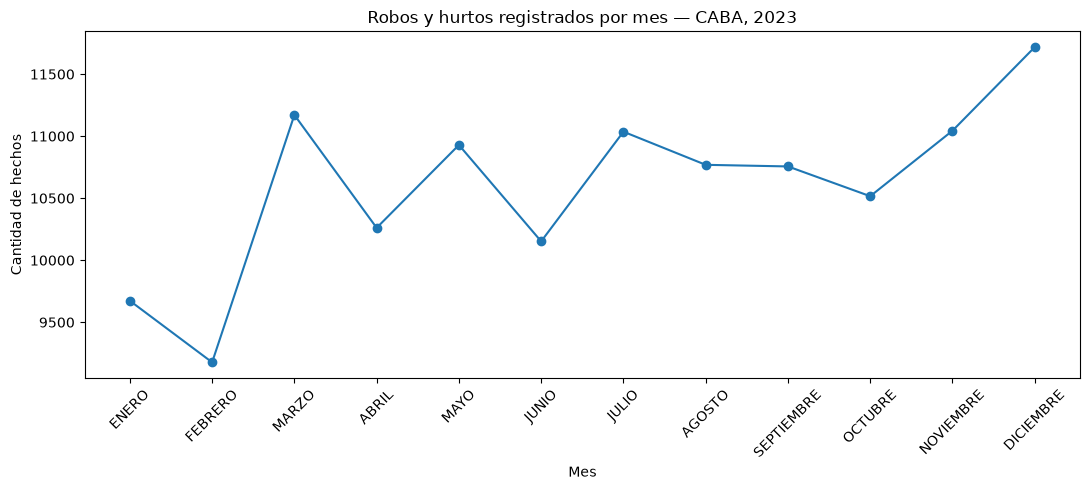

In [5]:
month_names = {
    1: "ENERO",
    2: "FEBRERO",
    3: "MARZO",
    4: "ABRIL",
    5: "MAYO",
    6: "JUNIO",
    7: "JULIO",
    8: "AGOSTO",
    9: "SEPTIEMBRE",
    10: "OCTUBRE",
    11: "NOVIEMBRE",
    12: "DICIEMBRE",
}

monthly_counts = (
    property_df
    .assign(numero_mes=property_df["fecha"].dt.month)
    .groupby("numero_mes", observed=False)
    .size()
    .reindex(range(1, 13), fill_value=0)
    .rename("cantidad")
    .reset_index()
)

monthly_counts["mes"] = monthly_counts["numero_mes"].map(month_names)
monthly_counts["porcentaje"] = (
    monthly_counts["cantidad"] / monthly_counts["cantidad"].sum() * 100
).round(2)

display(monthly_counts[["numero_mes", "mes", "cantidad", "porcentaje"]])

plt.figure(figsize=(11, 5))
plt.plot(
    monthly_counts["mes"],
    monthly_counts["cantidad"],
    marker="o",
)
plt.title("Robos y hurtos registrados por mes — CABA, 2023")
plt.xlabel("Mes")
plt.ylabel("Cantidad de hechos")
plt.xticks(rotation=45)
finish_plot("01_robos_hurtos_por_mes.png")

## 5. Evolución diaria y promedio móvil

La serie diaria muestra fluctuaciones puntuales. El promedio móvil de siete días suaviza esas oscilaciones y facilita la identificación de tendencias sin confundir ruido diario con cambios estructurales.

,fecha,cantidad,promedio_movil_7_dias
0,2023-01-01,258,258.00
1,2023-01-02,273,265.50
2,2023-01-03,308,279.67
3,2023-01-04,348,296.75
4,2023-01-05,318,301.00


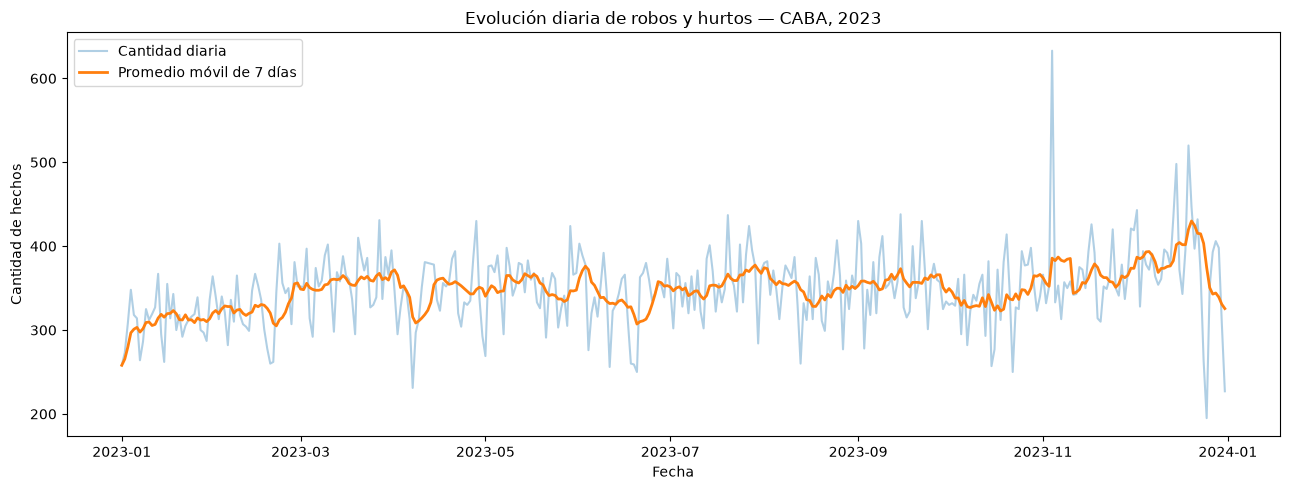

In [6]:
complete_dates = pd.date_range(
    property_df["fecha"].min(),
    property_df["fecha"].max(),
    freq="D",
)

daily_counts = (
    property_df
    .groupby("fecha")
    .size()
    .reindex(complete_dates, fill_value=0)
    .rename("cantidad")
    .rename_axis("fecha")
    .reset_index()
)

daily_counts["promedio_movil_7_dias"] = (
    daily_counts["cantidad"]
    .rolling(window=7, min_periods=1)
    .mean()
)

display(daily_counts.head())

plt.figure(figsize=(13, 5))
plt.plot(
    daily_counts["fecha"],
    daily_counts["cantidad"],
    alpha=0.35,
    label="Cantidad diaria",
)
plt.plot(
    daily_counts["fecha"],
    daily_counts["promedio_movil_7_dias"],
    linewidth=2,
    label="Promedio móvil de 7 días",
)
plt.title("Evolución diaria de robos y hurtos — CABA, 2023")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de hechos")
plt.legend()
finish_plot("02_evolucion_diaria_robos_hurtos.png")

## 6. Distribución por día de la semana

Para evitar una comparación engañosa entre totales, se calcula el **promedio de hechos por cada fecha** de lunes a domingo. Así se contempla que cada día de la semana aparece una cantidad ligeramente distinta de veces en el calendario.

,numero_dia,dia_semana,cantidad_total,cantidad_de_fechas,promedio_por_dia
0,0,LUNES,17937,52,344.94
1,1,MARTES,18238,52,350.73
2,2,MIÉRCOLES,18665,52,358.94
3,3,JUEVES,18740,52,360.38
4,4,VIERNES,19397,52,373.02
5,5,SÁBADO,18239,52,350.75
6,6,DOMINGO,15986,53,301.62


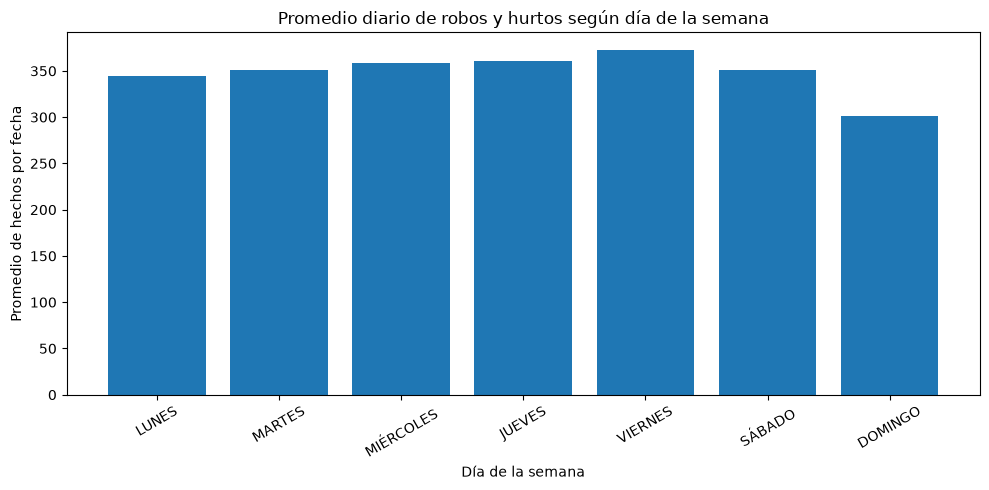

In [7]:
weekday_names = {
    0: "LUNES",
    1: "MARTES",
    2: "MIÉRCOLES",
    3: "JUEVES",
    4: "VIERNES",
    5: "SÁBADO",
    6: "DOMINGO",
}

daily_calendar = daily_counts.copy()
daily_calendar["numero_dia"] = daily_calendar["fecha"].dt.dayofweek
daily_calendar["dia_semana"] = (
    daily_calendar["numero_dia"].map(weekday_names)
)

weekday_summary = (
    daily_calendar
    .groupby(["numero_dia", "dia_semana"], observed=False)["cantidad"]
    .agg(
        cantidad_total="sum",
        cantidad_de_fechas="count",
        promedio_por_dia="mean",
    )
    .reset_index()
    .sort_values("numero_dia")
)

weekday_summary["promedio_por_dia"] = (
    weekday_summary["promedio_por_dia"].round(2)
)

display(weekday_summary)

plt.figure(figsize=(10, 5))
plt.bar(
    weekday_summary["dia_semana"],
    weekday_summary["promedio_por_dia"],
)
plt.title("Promedio diario de robos y hurtos según día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Promedio de hechos por fecha")
plt.xticks(rotation=30)
finish_plot("03_promedio_por_dia_semana.png")

## 7. Distribución horaria

Se analiza la hora informada en la variable `franja`, de 0 a 23. El objetivo es detectar horarios de mayor concentración para el conjunto de robos y hurtos, sin atribuir esas diferencias a la clasificación jurídica entre ambos delitos.

,franja,cantidad,porcentaje
0,0,3930,3.09
1,1,2819,2.22
2,2,2267,1.78
3,3,2431,1.91
4,4,2537,1.99
5,5,3132,2.46
6,6,4670,3.67
7,7,7008,5.51
8,8,7298,5.74
9,9,6053,4.76


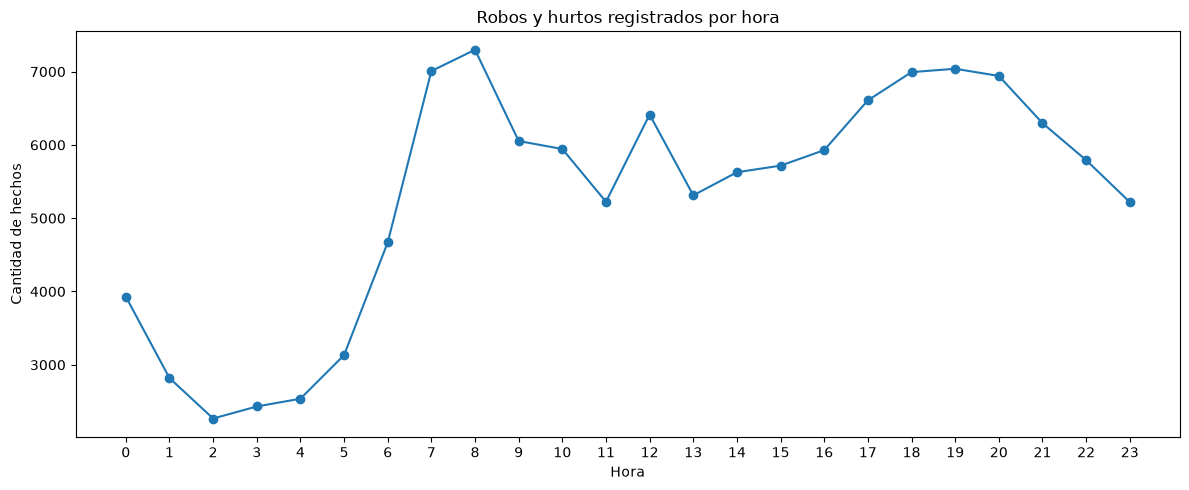

In [8]:
hourly_counts = (
    property_df
    .groupby("franja", observed=False)
    .size()
    .reindex(range(24), fill_value=0)
    .rename("cantidad")
    .reset_index()
)

hourly_counts["porcentaje"] = (
    hourly_counts["cantidad"] / hourly_counts["cantidad"].sum() * 100
).round(2)

display(hourly_counts)

plt.figure(figsize=(12, 5))
plt.plot(
    hourly_counts["franja"],
    hourly_counts["cantidad"],
    marker="o",
)
plt.title("Robos y hurtos registrados por hora")
plt.xlabel("Hora")
plt.ylabel("Cantidad de hechos")
plt.xticks(range(24))
finish_plot("04_robos_hurtos_por_hora.png")

,franja_horaria,cantidad,porcentaje
0,MADRUGADA,17116,13.46
1,MAÑANA,36197,28.46
2,TARDE,35607,27.99
3,NOCHE,38282,30.10


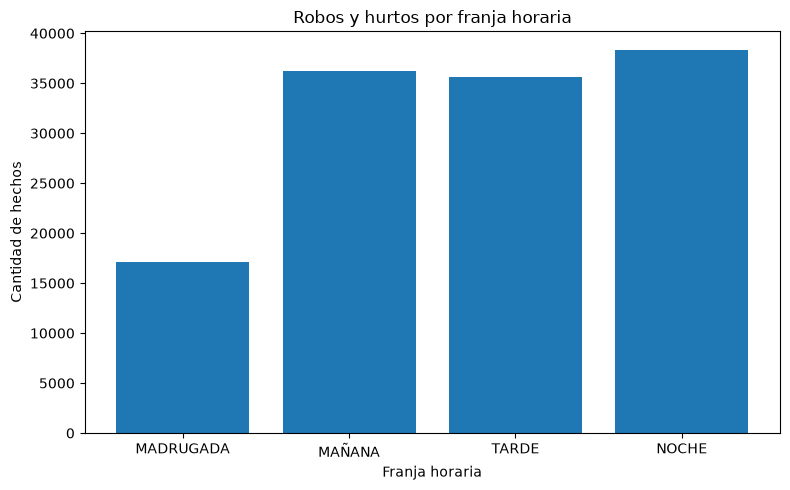

In [9]:
time_band_summary = (
    property_df
    .groupby("franja_horaria", observed=False)
    .size()
    .reindex(franja_order, fill_value=0)
    .rename("cantidad")
    .reset_index()
)

time_band_summary["porcentaje"] = (
    time_band_summary["cantidad"]
    / time_band_summary["cantidad"].sum()
    * 100
).round(2)

display(time_band_summary)

plt.figure(figsize=(8, 5))
plt.bar(
    time_band_summary["franja_horaria"].astype(str),
    time_band_summary["cantidad"],
)
plt.title("Robos y hurtos por franja horaria")
plt.xlabel("Franja horaria")
plt.ylabel("Cantidad de hechos")
finish_plot("05_robos_hurtos_por_franja_horaria.png")

## 8. Días hábiles y fines de semana

No se comparan únicamente los totales, porque el año contiene muchos más días hábiles que fines de semana. Se utiliza el promedio de hechos por fecha para cada grupo.

,tipo_dia,cantidad_total,cantidad_de_fechas,promedio_por_dia
0,DÍA HÁBIL,92977,260,357.60
1,FIN DE SEMANA,34225,105,325.95


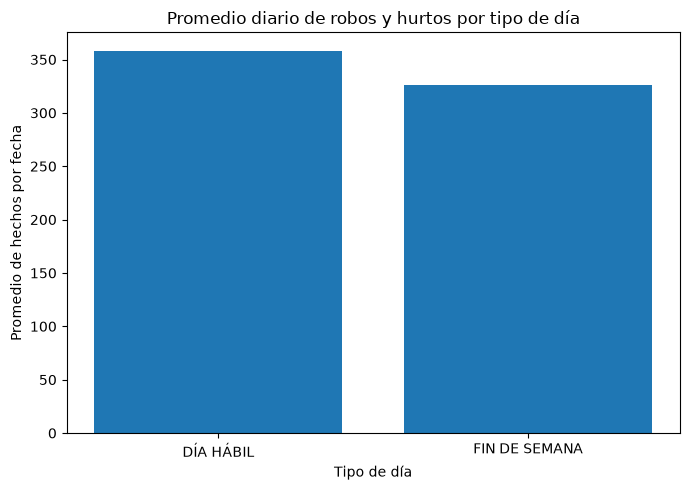

In [10]:
daily_calendar["tipo_dia"] = np.where(
    daily_calendar["numero_dia"].ge(5),
    "FIN DE SEMANA",
    "DÍA HÁBIL",
)

weekend_summary = (
    daily_calendar
    .groupby("tipo_dia")["cantidad"]
    .agg(
        cantidad_total="sum",
        cantidad_de_fechas="count",
        promedio_por_dia="mean",
    )
    .reset_index()
)

weekend_summary["promedio_por_dia"] = (
    weekend_summary["promedio_por_dia"].round(2)
)

display(weekend_summary)

plt.figure(figsize=(7, 5))
plt.bar(
    weekend_summary["tipo_dia"],
    weekend_summary["promedio_por_dia"],
)
plt.title("Promedio diario de robos y hurtos por tipo de día")
plt.xlabel("Tipo de día")
plt.ylabel("Promedio de hechos por fecha")
finish_plot("06_dias_habiles_vs_fin_semana.png")

## 9. Distribución espacial por comuna

Los valores representan **cantidades absolutas de hechos registrados**. Una comuna con más registros no necesariamente presenta mayor riesgo individual: para afirmar eso sería necesario incorporar población, circulación de personas u otra medida de exposición.

,comuna,cantidad,porcentaje
0,1,17071,13.42
1,2,6000,4.72
2,3,10548,8.29
3,4,11005,8.65
4,5,6886,5.41
5,6,5510,4.33
6,7,9573,7.53
7,8,7743,6.09
8,9,7550,5.94
9,10,5777,4.54


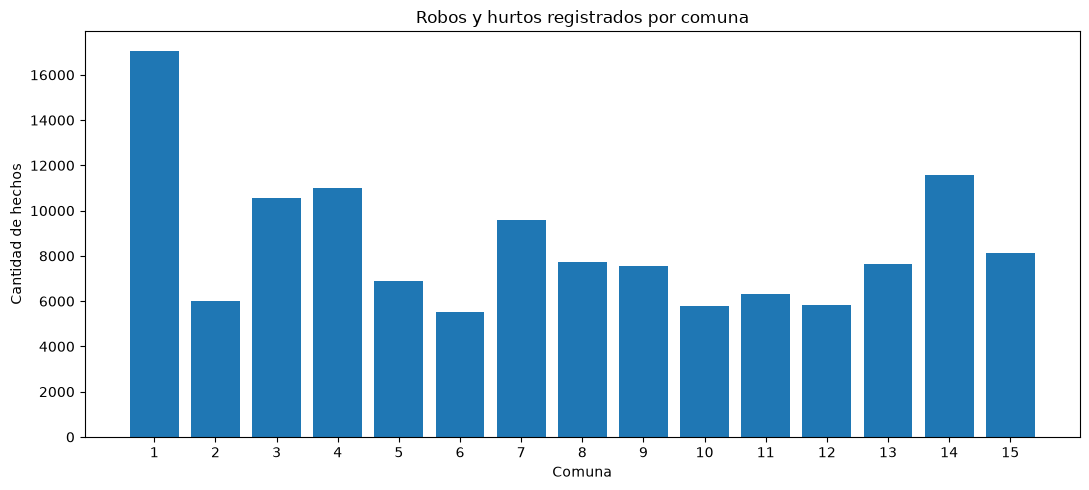

In [11]:
commune_summary = (
    property_df
    .groupby("comuna", observed=False)
    .size()
    .rename("cantidad")
    .reset_index()
    .sort_values("comuna")
)

commune_summary["porcentaje"] = (
    commune_summary["cantidad"]
    / commune_summary["cantidad"].sum()
    * 100
).round(2)

display(commune_summary)

plt.figure(figsize=(11, 5))
plt.bar(
    commune_summary["comuna"].astype(str),
    commune_summary["cantidad"],
)
plt.title("Robos y hurtos registrados por comuna")
plt.xlabel("Comuna")
plt.ylabel("Cantidad de hechos")
finish_plot("07_robos_hurtos_por_comuna.png")

## 10. Barrios con mayor cantidad de registros

Se muestran los quince barrios con más hechos registrados. El ranking describe concentración de denuncias o registros, no una tasa ajustada por habitantes o población flotante.

,barrio,cantidad,porcentaje
20,PALERMO,11570,9.10
2,BALVANERA,8605,6.76
12,FLORES,6726,5.29
27,RECOLETA,6000,4.72
7,CABALLITO,5510,4.33
1,ALMAGRO,5282,4.15
31,SAN NICOLAS,4970,3.91
39,VILLA LUGANO,4637,3.65
3,BARRACAS,4250,3.34
4,BELGRANO,4217,3.32


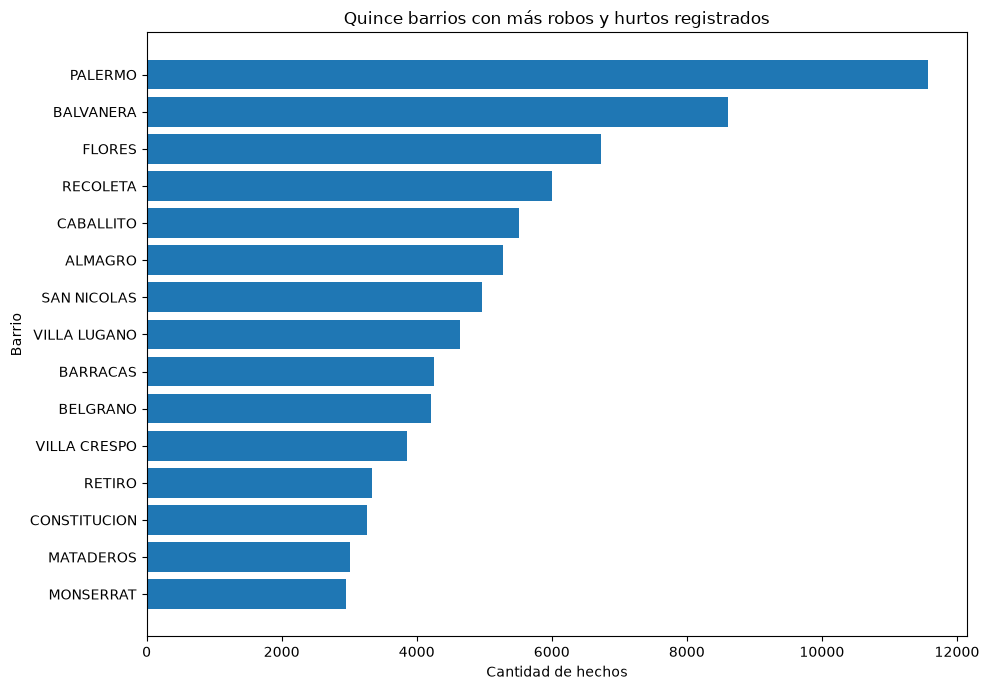

In [12]:
neighborhood_summary = (
    property_df
    .groupby("barrio", observed=False)
    .size()
    .rename("cantidad")
    .reset_index()
    .sort_values("cantidad", ascending=False)
)

neighborhood_summary["porcentaje"] = (
    neighborhood_summary["cantidad"]
    / neighborhood_summary["cantidad"].sum()
    * 100
).round(2)

top_neighborhoods = neighborhood_summary.head(15).copy()

display(top_neighborhoods)

plt.figure(figsize=(10, 7))
plt.barh(
    top_neighborhoods["barrio"][::-1],
    top_neighborhoods["cantidad"][::-1],
)
plt.title("Quince barrios con más robos y hurtos registrados")
plt.xlabel("Cantidad de hechos")
plt.ylabel("Barrio")
finish_plot("08_top_15_barrios.png")

## 11. Concentración geográfica de puntos

El gráfico hexagonal resume la densidad de registros sin intentar dibujar un mapa administrativo. Resulta más legible que representar más de cien mil puntos individuales superpuestos.

Las coordenadas ya fueron normalizadas y validadas en el Notebook 01.

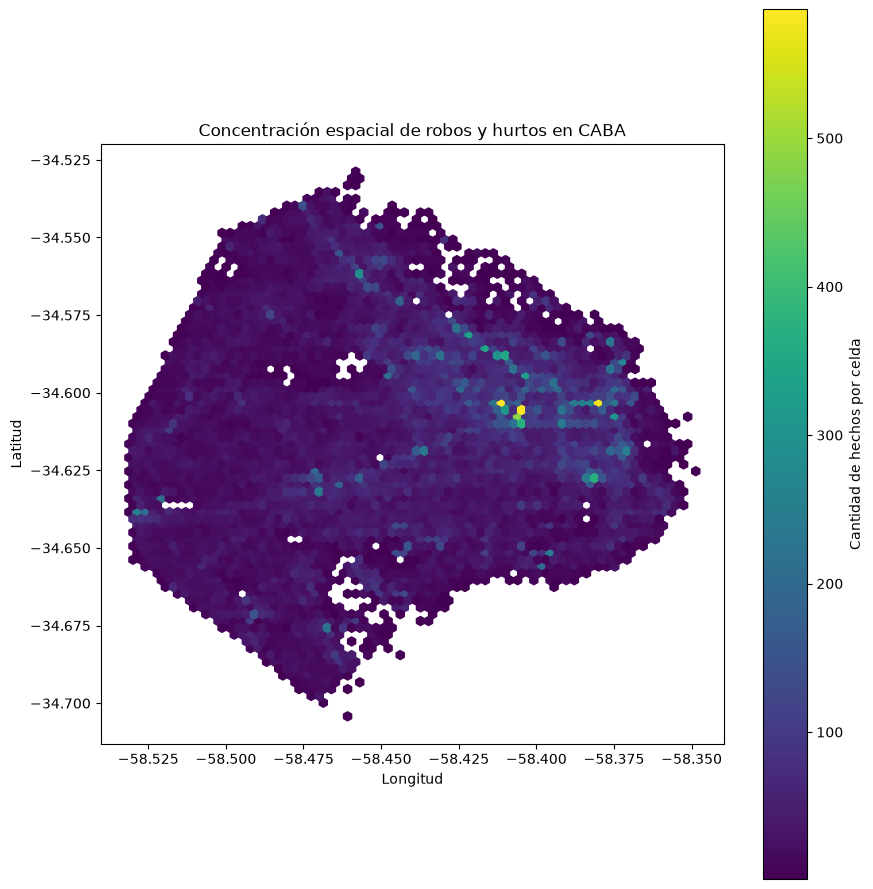

In [13]:
plt.figure(figsize=(9, 9))
hexbin = plt.hexbin(
    property_df["longitud"],
    property_df["latitud"],
    gridsize=70,
    mincnt=1,
)
plt.colorbar(hexbin, label="Cantidad de hechos por celda")
plt.title("Concentración espacial de robos y hurtos en CABA")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.gca().set_aspect("equal", adjustable="box")
finish_plot("09_concentracion_espacial_hexbin.png")

## 12. Uso informado de armas y motos

Estas variables se analizan para el conjunto agregado de robos y hurtos. Son campos declarativos del dataset: describen lo registrado y no permiten inferir por sí solos la dinámica completa del hecho.

Uso informado de armas:


,uso_arma,cantidad,porcentaje
0,NO,117975,92.75
1,SI,9227,7.25


Uso informado de motos:


,uso_moto,cantidad,porcentaje
0,NO,122768,96.51
1,SI,4434,3.49


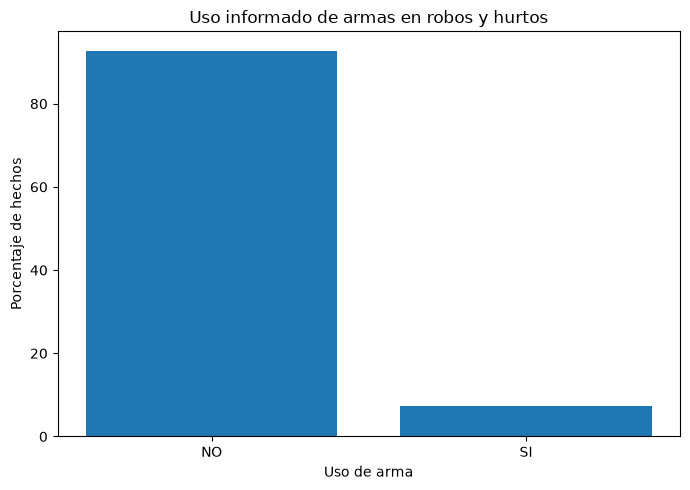

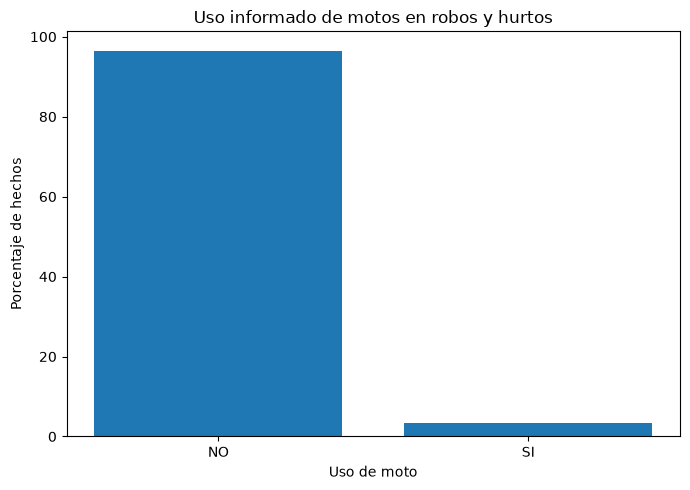

In [14]:
for column in ["uso_arma", "uso_moto"]:
    property_df[column] = (
        property_df[column]
        .astype("string")
        .str.strip()
        .str.upper()
        .fillna("SIN DATO")
    )

weapon_summary = (
    property_df["uso_arma"]
    .value_counts(dropna=False)
    .rename_axis("uso_arma")
    .reset_index(name="cantidad")
)

weapon_summary["porcentaje"] = (
    weapon_summary["cantidad"]
    / weapon_summary["cantidad"].sum()
    * 100
).round(2)

motorcycle_summary = (
    property_df["uso_moto"]
    .value_counts(dropna=False)
    .rename_axis("uso_moto")
    .reset_index(name="cantidad")
)

motorcycle_summary["porcentaje"] = (
    motorcycle_summary["cantidad"]
    / motorcycle_summary["cantidad"].sum()
    * 100
).round(2)

print("Uso informado de armas:")
display(weapon_summary)

print("Uso informado de motos:")
display(motorcycle_summary)

plt.figure(figsize=(7, 5))
plt.bar(
    weapon_summary["uso_arma"],
    weapon_summary["porcentaje"],
)
plt.title("Uso informado de armas en robos y hurtos")
plt.xlabel("Uso de arma")
plt.ylabel("Porcentaje de hechos")
finish_plot("10_uso_informado_armas.png")

plt.figure(figsize=(7, 5))
plt.bar(
    motorcycle_summary["uso_moto"],
    motorcycle_summary["porcentaje"],
)
plt.title("Uso informado de motos en robos y hurtos")
plt.xlabel("Uso de moto")
plt.ylabel("Porcentaje de hechos")
finish_plot("11_uso_informado_motos.png")

## 13. Perfil temporal de cada comuna

Para comparar comunas con cantidades totales muy diferentes, la tabla se normaliza por fila. Cada celda muestra qué porcentaje de los hechos de una comuna ocurrió en cada franja horaria.

Esto permite observar perfiles temporales relativos sin confundirlos con el volumen total de cada comuna.

franja_horaria,MADRUGADA,MAÑANA,TARDE,NOCHE
comuna,,,,
1,14.39,23.04,30.35,32.22
2,13.18,23.62,32.33,30.87
3,11.65,23.27,33.98,31.10
4,14.06,31.31,27.50,27.13
5,13.59,29.26,25.56,31.59
6,10.83,30.49,29.38,29.29
7,12.02,32.59,30.26,25.12
8,13.77,32.36,25.48,28.39
9,12.70,33.62,24.37,29.31


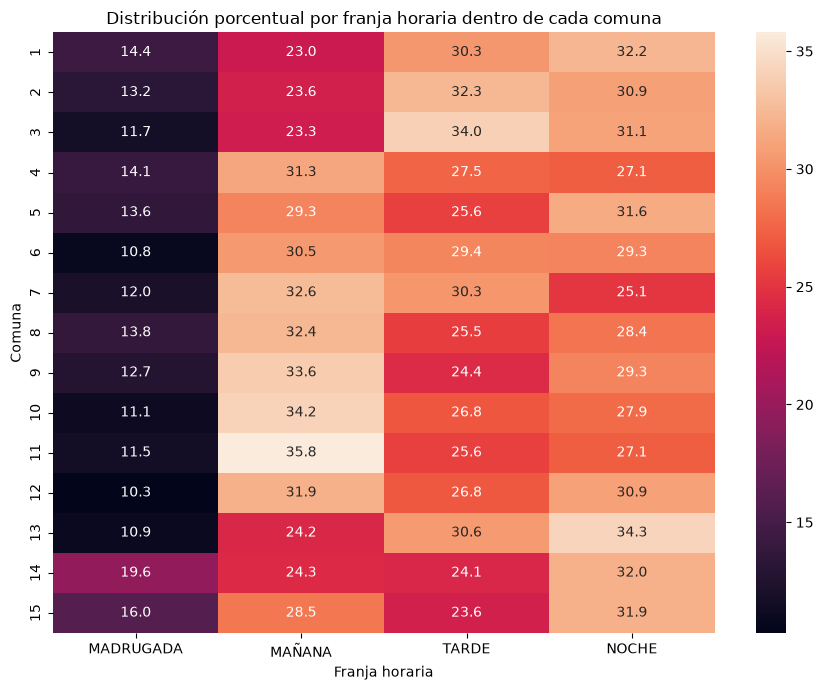

In [15]:
commune_time_profile = pd.crosstab(
    property_df["comuna"],
    property_df["franja_horaria"],
    normalize="index",
).reindex(columns=franja_order, fill_value=0) * 100

display(commune_time_profile.round(2))

plt.figure(figsize=(9, 7))
sns.heatmap(
    commune_time_profile,
    annot=True,
    fmt=".1f",
)
plt.title("Distribución porcentual por franja horaria dentro de cada comuna")
plt.xlabel("Franja horaria")
plt.ylabel("Comuna")
finish_plot("12_perfil_temporal_por_comuna.png")

## 14. Tabla combinada de barrio y franja horaria

Se construye una tabla para los barrios con mayor volumen. La normalización por fila permite comparar el patrón horario interno de cada barrio, no su cantidad total.

franja_horaria,MADRUGADA,MAÑANA,TARDE,NOCHE
barrio,,,,
PALERMO,19.64,24.26,24.13,31.97
BALVANERA,11.44,21.71,35.83,31.03
FLORES,11.49,31.55,31.92,25.04
RECOLETA,13.18,23.62,32.33,30.87
CABALLITO,10.83,30.49,29.38,29.29
ALMAGRO,14.60,27.43,25.58,32.39
SAN NICOLAS,11.09,20.56,30.02,38.33
VILLA LUGANO,14.28,33.71,23.68,28.34
BARRACAS,13.67,31.25,29.08,26.00


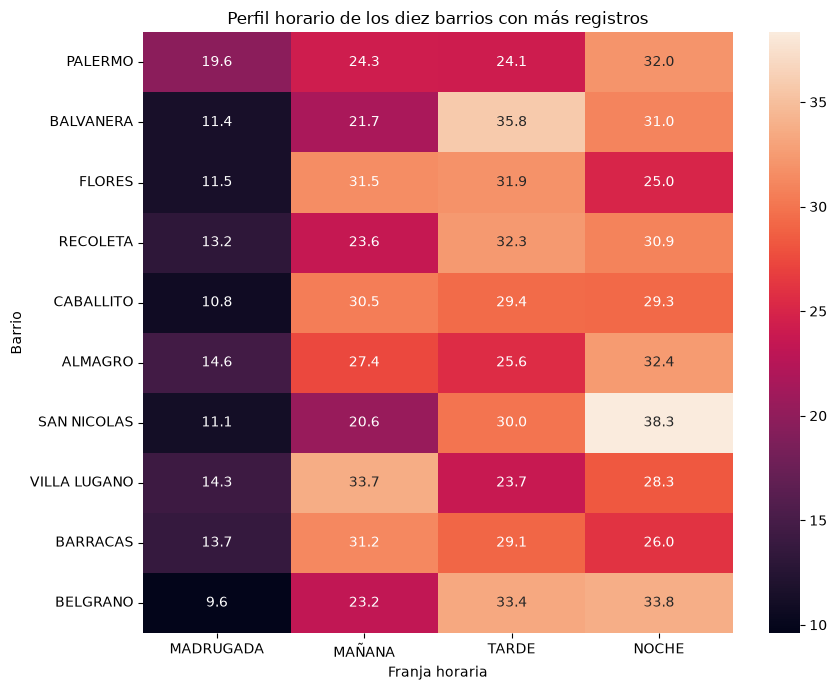

In [16]:
top_10_neighborhood_names = (
    neighborhood_summary
    .head(10)["barrio"]
    .tolist()
)

top_neighborhood_time_profile = pd.crosstab(
    property_df.loc[
        property_df["barrio"].isin(top_10_neighborhood_names),
        "barrio",
    ],
    property_df.loc[
        property_df["barrio"].isin(top_10_neighborhood_names),
        "franja_horaria",
    ],
    normalize="index",
).reindex(columns=franja_order, fill_value=0) * 100

# Ordena las filas según el ranking general de cantidad.
top_neighborhood_time_profile = (
    top_neighborhood_time_profile
    .reindex(top_10_neighborhood_names)
)

display(top_neighborhood_time_profile.round(2))

plt.figure(figsize=(9, 7))
sns.heatmap(
    top_neighborhood_time_profile,
    annot=True,
    fmt=".1f",
)
plt.title("Perfil horario de los diez barrios con más registros")
plt.xlabel("Franja horaria")
plt.ylabel("Barrio")
finish_plot("13_perfil_temporal_top_10_barrios.png")

## 15. Exportación de resultados

Se guardan las principales tablas agregadas para reutilizarlas en el informe, la presentación o futuros notebooks. El dataset original y el dataset limpio no se modifican.

In [17]:
tables_to_export = {
    "eda_resumen_general.csv": analysis_summary,
    "eda_robos_hurtos_por_mes.csv": monthly_counts,
    "eda_robos_hurtos_por_dia.csv": daily_counts,
    "eda_robos_hurtos_por_dia_semana.csv": weekday_summary,
    "eda_robos_hurtos_por_hora.csv": hourly_counts,
    "eda_robos_hurtos_por_franja.csv": time_band_summary,
    "eda_robos_hurtos_habil_fin_semana.csv": weekend_summary,
    "eda_robos_hurtos_por_comuna.csv": commune_summary,
    "eda_robos_hurtos_por_barrio.csv": neighborhood_summary,
    "eda_uso_armas.csv": weapon_summary,
    "eda_uso_motos.csv": motorcycle_summary,
    "eda_perfil_temporal_comunas.csv": (
        commune_time_profile
        .round(4)
        .reset_index()
    ),
    "eda_perfil_temporal_top_barrios.csv": (
        top_neighborhood_time_profile
        .round(4)
        .reset_index()
    ),
}

for filename, table in tables_to_export.items():
    table.to_csv(
        TABLES_DIR / filename,
        index=False,
        encoding="utf-8-sig",
    )

print("Tablas exportadas:")
for filename in tables_to_export:
    print(f" - {TABLES_DIR / filename}")

print("\nFiguras generadas:")
for figure_path in sorted(FIGURES_DIR.glob("*.png")):
    print(f" - {figure_path}")

Tablas exportadas:
 - C:\Users\nikko\CienciaDatosDelitosTPO\reports\tables\eda_resumen_general.csv
 - C:\Users\nikko\CienciaDatosDelitosTPO\reports\tables\eda_robos_hurtos_por_mes.csv
 - C:\Users\nikko\CienciaDatosDelitosTPO\reports\tables\eda_robos_hurtos_por_dia.csv
 - C:\Users\nikko\CienciaDatosDelitosTPO\reports\tables\eda_robos_hurtos_por_dia_semana.csv
 - C:\Users\nikko\CienciaDatosDelitosTPO\reports\tables\eda_robos_hurtos_por_hora.csv
 - C:\Users\nikko\CienciaDatosDelitosTPO\reports\tables\eda_robos_hurtos_por_franja.csv
 - C:\Users\nikko\CienciaDatosDelitosTPO\reports\tables\eda_robos_hurtos_habil_fin_semana.csv
 - C:\Users\nikko\CienciaDatosDelitosTPO\reports\tables\eda_robos_hurtos_por_comuna.csv
 - C:\Users\nikko\CienciaDatosDelitosTPO\reports\tables\eda_robos_hurtos_por_barrio.csv
 - C:\Users\nikko\CienciaDatosDelitosTPO\reports\tables\eda_uso_armas.csv
 - C:\Users\nikko\CienciaDatosDelitosTPO\reports\tables\eda_uso_motos.csv
 - C:\Users\nikko\CienciaDatosDelitosTPO\report

## 16. Resumen automático de hallazgos

La siguiente celda identifica los máximos principales directamente desde los datos. Así se evita escribir conclusiones que queden desactualizadas si cambia el archivo.

In [18]:
peak_month = monthly_counts.loc[
    monthly_counts["cantidad"].idxmax()
]

peak_weekday = weekday_summary.loc[
    weekday_summary["promedio_por_dia"].idxmax()
]

peak_hour = hourly_counts.loc[
    hourly_counts["cantidad"].idxmax()
]

peak_time_band = time_band_summary.loc[
    time_band_summary["cantidad"].idxmax()
]

peak_commune = commune_summary.loc[
    commune_summary["cantidad"].idxmax()
]

peak_neighborhood = neighborhood_summary.loc[
    neighborhood_summary["cantidad"].idxmax()
]

weapon_yes = weapon_summary.loc[
    weapon_summary["uso_arma"].eq("SI"),
    "porcentaje",
]

motorcycle_yes = motorcycle_summary.loc[
    motorcycle_summary["uso_moto"].eq("SI"),
    "porcentaje",
]

weapon_yes_pct = (
    float(weapon_yes.iloc[0])
    if not weapon_yes.empty
    else np.nan
)

motorcycle_yes_pct = (
    float(motorcycle_yes.iloc[0])
    if not motorcycle_yes.empty
    else np.nan
)

print("RESUMEN DEL ANÁLISIS EXPLORATORIO")
print("-" * 45)
print(
    f"• Se analizaron {len(property_df):,} robos y hurtos "
    "como una única población."
)
print(
    f"• El mes con más registros fue {peak_month['mes']}, "
    f"con {int(peak_month['cantidad']):,} hechos."
)
print(
    f"• El mayor promedio diario correspondió a "
    f"{peak_weekday['dia_semana']}, con "
    f"{peak_weekday['promedio_por_dia']:.2f} hechos por fecha."
)
print(
    f"• La hora con más registros fue {int(peak_hour['franja']):02d}:00, "
    f"con {int(peak_hour['cantidad']):,} hechos."
)
print(
    f"• La franja con mayor cantidad fue "
    f"{peak_time_band['franja_horaria']}, con "
    f"{int(peak_time_band['cantidad']):,} hechos."
)
print(
    f"• La comuna con más registros fue la "
    f"{int(peak_commune['comuna'])}, con "
    f"{int(peak_commune['cantidad']):,} hechos."
)
print(
    f"• El barrio con más registros fue "
    f"{peak_neighborhood['barrio']}, con "
    f"{int(peak_neighborhood['cantidad']):,} hechos."
)

if not np.isnan(weapon_yes_pct):
    print(
        f"• El uso de arma fue informado en "
        f"{weapon_yes_pct:.2f}% de los hechos."
    )

if not np.isnan(motorcycle_yes_pct):
    print(
        f"• El uso de moto fue informado en "
        f"{motorcycle_yes_pct:.2f}% de los hechos."
    )

RESUMEN DEL ANÁLISIS EXPLORATORIO
---------------------------------------------
• Se analizaron 127,202 robos y hurtos como una única población.
• El mes con más registros fue DICIEMBRE, con 11,718 hechos.
• El mayor promedio diario correspondió a VIERNES, con 373.02 hechos por fecha.
• La hora con más registros fue 08:00, con 7,298 hechos.
• La franja con mayor cantidad fue NOCHE, con 38,282 hechos.
• La comuna con más registros fue la 1, con 17,071 hechos.
• El barrio con más registros fue PALERMO, con 11,570 hechos.
• El uso de arma fue informado en 7.25% de los hechos.
• El uso de moto fue informado en 3.49% de los hechos.


## 17. Criterios para interpretar los resultados

1. **Robo y Hurto se estudian conjuntamente.** La separación jurídica permanece en la fuente por trazabilidad, pero no es una dimensión explicativa de este EDA.
2. **Los gráficos muestran registros, no necesariamente todos los hechos ocurridos.** Puede existir subregistro o variación en la propensión a denunciar.
3. **Las cantidades por barrio o comuna no son tasas de riesgo.** Para calcular tasas sería necesario incorporar población residente, población flotante u otra medida de exposición.
4. **Una concentración temporal o espacial no prueba causalidad.** El EDA detecta patrones descriptivos que luego pueden orientar modelos o hipótesis.
5. **No se imputaron ubicaciones.** El análisis espacial utiliza únicamente los 152.739 registros válidos definidos en el Notebook 01.
6. **Las variables de arma y moto describen lo informado en la base.** No deben interpretarse como una reconstrucción jurídica completa de cada hecho.

### Resultado metodológico

El notebook queda centrado en la pregunta útil para el proyecto: **cómo se distribuyen temporal y espacialmente los robos y hurtos registrados en CABA durante 2023**, tratados como un único fenómeno analítico.